# List Experiment Analysis

This notebook analyzes the original 14-item list experiment using the precomputed CSV files in `outputs/first_part_original/`.

Main quantities:

$$\pi_{LE,i} = \overline{Y}_{i,treatment} - \overline{Y}_{i,control}$$

$$Bias_{LE,i} = \pi_{LE,i} - \pi_{ALLBUS,i}$$

In [2]:
import os
os.chdir("/home/sar88180/csslab-llm-bias")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("outputs/first_part_original")
FIG_DIR = OUTPUT_DIR / "notebook_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

item = pd.read_csv(OUTPUT_DIR / "first_part_item_summary.csv")
model = pd.read_csv(OUTPUT_DIR / "first_part_model_summary.csv")

## Model-Level Summary

In [3]:
model_display = model.copy()
model_display["invalid_pct"] = model_display["mean_invalid_rate"] * 100
model_display["Prompting"] = model_display["bucket"].replace({
    "persona": "Persona",
    "no_persona": "No persona",
})
model_display["Model"] = model_display["model_label"].replace({
    "Qwen3-8B": "Qwen3-8B",
    "Llama-70B": "Llama-3.1-70B-Instruct",
    "Mistral-7B": "Mistral-7B-Instruct-v0.3",
})
model_display["model_order"] = model_display["model_label"].map({
    "Qwen3-8B": 0,
    "Llama-70B": 1,
    "Mistral-7B": 2,
})
model_display["prompt_order"] = model_display["bucket"].map({
    "no_persona": 0,
    "persona": 1,
})
model_display = model_display.sort_values(["prompt_order", "model_order"])
model_display = model_display[[
    "Model",
    "Prompting",
    "mean_abs_bias_le",
    "mean_bias_le",
    "sd_bias_le",
    "avg_response_sd",
    "invalid_pct",
]]
model_display.round(3)


,Model,Prompting,mean_abs_bias_le,mean_bias_le,sd_bias_le,avg_response_sd,invalid_pct
2,Qwen3-8B,No persona,0.197,-0.014,0.244,0.635,0.000
0,Llama-3.1-70B-Instruct,No persona,0.327,-0.327,0.241,0.259,0.000
1,Mistral-7B-Instruct-v0.3,No persona,0.377,0.373,0.212,0.371,0.000
5,Qwen3-8B,Persona,0.224,0.224,0.165,0.499,0.131
3,Llama-3.1-70B-Instruct,Persona,0.207,0.137,0.195,0.412,0.000
4,Mistral-7B-Instruct-v0.3,Persona,0.606,-0.472,0.521,1.607,22.822


In [4]:
latex_table = model_display.rename(columns={
    "mean_abs_bias_le": "MAE",
    "mean_bias_le": "Mean Bias",
    "sd_bias_le": r"SD Bias$_{LE}$",
    "avg_response_sd": "Avg. Response SD",
    "invalid_pct": r"Invalid \%",
})
latex_table = latex_table[[
    "Model",
    "Prompting",
    "MAE",
    "Mean Bias",
    r"SD Bias$_{LE}$",
    "Avg. Response SD",
    r"Invalid \%",
]]

caption = (
    r"Analysis across all evaluated large language models and prompting conditions. "
    r"Metrics report mean absolute bias (MAE = Mean($|\pi_{LE} - \pi_{ALLBUS}|$)), "
    r"mean bias (Mean($\pi_{LE} - \pi_{ALLBUS}$)), standard deviation of the "
    r"list-experiment bias (SD of $\mathrm{Bias}_{LE}$), average standard deviation of raw "
    r"model responses (Avg. Response SD), and invalid response rate across all 14 ALLBUS variables."
)

tabular = latex_table.to_latex(index=False, float_format="%.3f", escape=False)
latex = "\n".join([
    r"\begin{table*}[htbp]",
    r"\centering",
    rf"\caption{{{caption}}}",
    r"\label{tab:list_experiment_model_summary}",
    r"\small",
    tabular,
    r"\end{table*}",
])
print(latex)

tex_path = OUTPUT_DIR / "list_experiment_model_summary_table.tex"
tex_path.write_text(latex, encoding="utf-8")
print(f"\nSaved LaTeX table to {tex_path}")


\begin{table*}[htbp]
\centering
\caption{Analysis across all evaluated large language models and prompting conditions. Metrics report mean absolute bias (MAE = Mean($|\pi_{LE} - \pi_{ALLBUS}|$)), mean bias (Mean($\pi_{LE} - \pi_{ALLBUS}$)), standard deviation of the list-experiment bias (SD of $\mathrm{Bias}_{LE}$), average standard deviation of raw model responses (Avg. Response SD), and invalid response rate across all 14 ALLBUS variables.}
\label{tab:list_experiment_model_summary}
\small
\begin{tabular}{llrrrrr}
\toprule
Model & Prompting & MAE & Mean Bias & SD Bias$_{LE}$ & Avg. Response SD & Invalid \% \\
\midrule
Qwen3-8B & No persona & 0.197 & -0.014 & 0.244 & 0.635 & 0.000 \\
Llama-3.1-70B-Instruct & No persona & 0.327 & -0.327 & 0.241 & 0.259 & 0.000 \\
Mistral-7B-Instruct-v0.3 & No persona & 0.377 & 0.373 & 0.212 & 0.371 & 0.000 \\
Qwen3-8B & Persona & 0.224 & 0.224 & 0.165 & 0.499 & 0.131 \\
Llama-3.1-70B-Instruct & Persona & 0.207 & 0.137 & 0.195 & 0.412 & 0.000 \\
Mistral-

## Mean Absolute Bias by Model

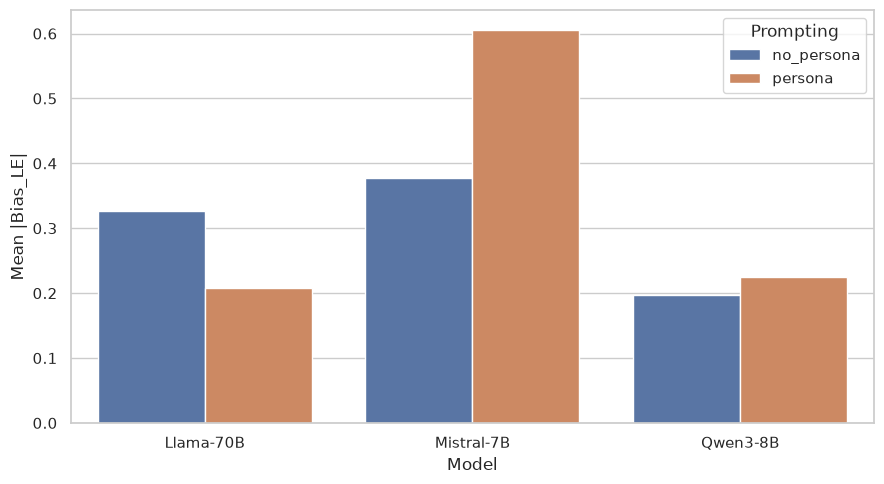

In [5]:
plt.figure(figsize=(9, 5))
sns.barplot(data=model, x="model_label", y="mean_abs_bias_le", hue="bucket")
plt.ylabel("Mean |Bias_LE|")
plt.xlabel("Model")
plt.legend(title="Prompting")
plt.tight_layout()
plt.savefig(FIG_DIR / "mean_abs_bias_by_model.png", dpi=200)
plt.show()

## Item-Level Bias

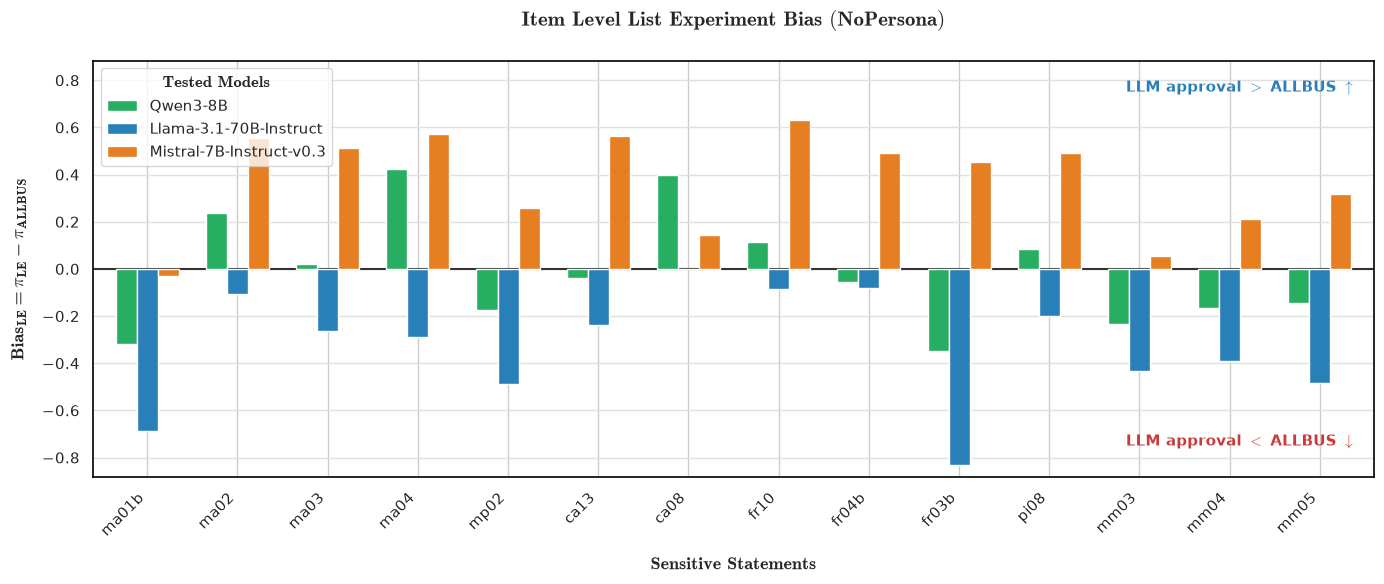

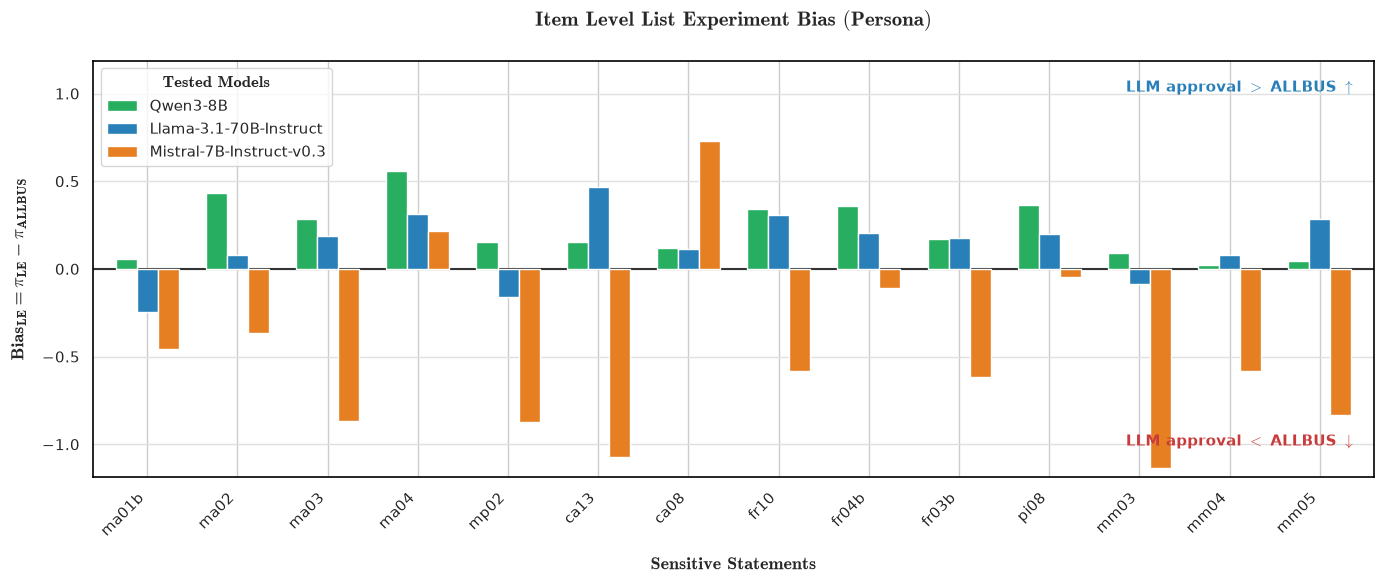

In [6]:
def plot_item_level_bias(bucket, output_filename):
    model_order = ["Qwen3-8B", "Llama-70B", "Mistral-7B"]
    model_names = {
        "Qwen3-8B": "Qwen3-8B",
        "Llama-70B": "Llama-3.1-70B-Instruct",
        "Mistral-7B": "Mistral-7B-Instruct-v0.3",
    }
    colors = {
        "Qwen3-8B": "#27AE60",
        "Llama-70B": "#2980B9",
        "Mistral-7B": "#E67E22",
    }

    plot_df = item[item["bucket"] == bucket].copy()
    plot_df["sensitive_number"] = plot_df["sensitive_id"].str.replace("sens_", "").astype(int)
    plot_df = plot_df.sort_values(["sensitive_number", "model_label"])

    sensitive_items = plot_df[["sensitive_id", "allbus_variable", "sensitive_number"]].drop_duplicates()
    sensitive_items = sensitive_items.sort_values("sensitive_number")
    x = np.arange(len(sensitive_items))

    available_models = [model for model in model_order if model in plot_df["model_label"].unique()]
    width = 0.7 / len(available_models)

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
    })

    plt.figure(figsize=(14, 6))
    ax = plt.gca()
    ax.set_facecolor("white")
    plt.grid(True, axis="y", color="#E0E0E0", linestyle="-", linewidth=1.0, zorder=1)

    for i, model in enumerate(available_models):
        model_df = plot_df[plot_df["model_label"] == model].set_index("sensitive_id")
        values = [model_df.loc[sid, "bias_le"] for sid in sensitive_items["sensitive_id"]]
        offset = (i - (len(available_models) - 1) / 2) * width
        plt.bar(
            x + offset,
            values,
            width,
            label=model_names[model],
            color=colors[model],
            zorder=3,
        )

    plt.axhline(y=0, color="#333333", linestyle="-", linewidth=1.5, zorder=2)

    plt.ylabel(r"$\mathbf{Bias_{LE} = \pi_{LE} - \pi_{ALLBUS}}$", fontsize=13, labelpad=10)
    plt.xlabel(r"$\mathbf{Sensitive\ Statements}$", fontsize=13, labelpad=12)
    plt.xticks(x, sensitive_items["allbus_variable"], rotation=45, ha="right", fontsize=11)
    plt.yticks(fontsize=11)

    max_val = plot_df["bias_le"].abs().max() + 0.05
    plt.ylim(-max_val, max_val)
    plt.xlim(-0.6, len(sensitive_items) - 0.4)

    ax.text(
        len(sensitive_items) - 0.6,
        max_val * 0.85,
        r"LLM approval $>$ ALLBUS $\uparrow$",
        color="#2980B9",
        fontsize=11,
        fontweight="bold",
        ha="right",
    )
    ax.text(
        len(sensitive_items) - 0.6,
        -max_val * 0.85,
        r"LLM approval $<$ ALLBUS $\downarrow$",
        color="#C93B3B",
        fontsize=11,
        fontweight="bold",
        ha="right",
    )


    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    plt.legend(
        title=r"$\mathbf{Tested\ Models}$",
        title_fontsize="12",
        fontsize="11",
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#CCCCCC",
    )
    plt.title(
        rf"$\mathbf{{Item\ Level\ List\ Experiment\ Bias\ ({bucket.replace('_', ' ').title()})}}$",
        fontsize=15,
        pad=25,
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / output_filename, dpi=300)
    plt.show()


plot_item_level_bias("no_persona", "item_level_bias_no_persona.png")
plot_item_level_bias("persona", "item_level_bias_persona.png")


## $\pi_{LE}$ Compared with ALLBUS

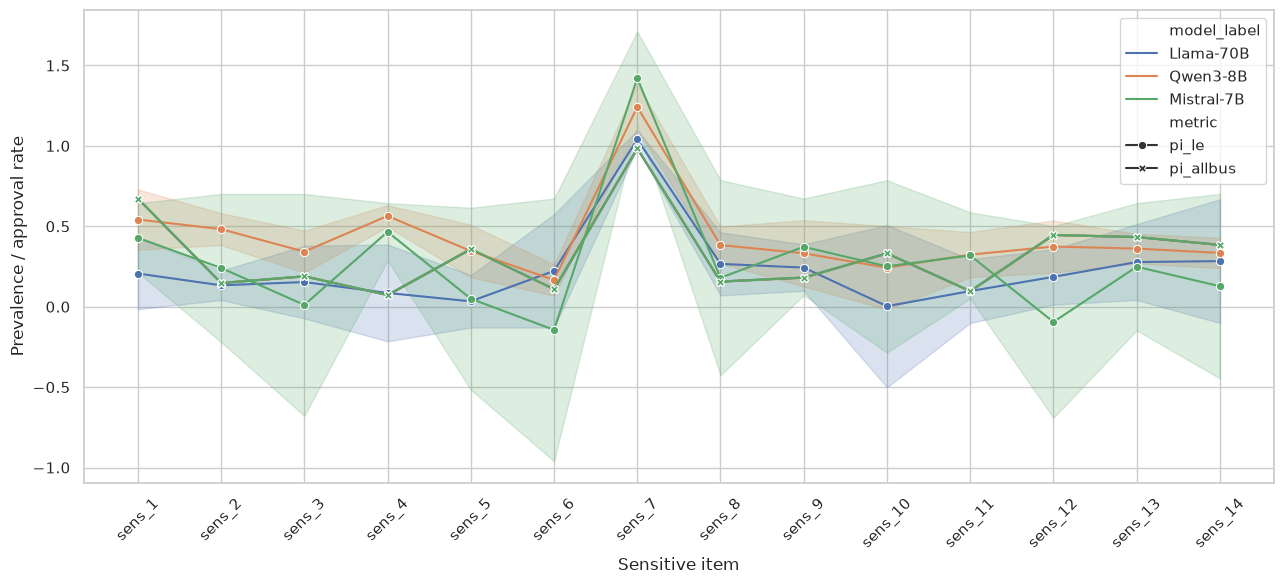

In [20]:
plot_data = item.melt(
    id_vars=["bucket", "model_label", "sensitive_id"],
    value_vars=["pi_le", "pi_allbus"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=plot_data,
    x="sensitive_id",
    y="value",
    hue="model_label",
    style="metric",
    markers=True,
    dashes=False,
)
plt.ylabel("Prevalence / approval rate")
plt.xlabel("Sensitive item")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "pi_le_vs_allbus_by_model.png", dpi=200)
plt.show()

## Detailed Item Table

In [21]:
item_table = item[[
    "bucket",
    "model_label",
    "sensitive_id",
    "allbus_variable",
    "pi_allbus",
    "pi_le",
    "bias_le",
    "ci_lower",
    "ci_upper",
    "p_value",
    "n_valid_control",
    "n_valid_treatment",
    "invalid_rate_total",
]].copy()

item_table["invalid_pct"] = item_table["invalid_rate_total"] * 100
item_table.round(3)

,bucket,model_label,sensitive_id,allbus_variable,pi_allbus,pi_le,bias_le,ci_lower,ci_upper,p_value,n_valid_control,n_valid_treatment,invalid_rate_total,invalid_pct
0,no_persona,Llama-70B,sens_1,ma01b,0.672,-0.015,-0.688,-0.179,0.149,0.851,24,35,0.000,0.000
1,no_persona,Llama-70B,sens_2,ma02,0.147,0.042,-0.106,-0.045,0.128,0.328,24,35,0.000,0.000
2,no_persona,Llama-70B,sens_3,ma03,0.189,-0.073,-0.262,-0.210,0.065,0.295,24,35,0.000,0.000
3,no_persona,Llama-70B,sens_4,ma04,0.073,-0.215,-0.288,-0.388,-0.043,0.015,24,35,0.000,0.000
4,no_persona,Llama-70B,sens_5,mp02,0.358,-0.130,-0.488,-0.284,0.024,0.097,24,35,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,persona,Mistral-7B,sens_10,fr03b,0.332,-0.285,-0.617,-0.362,-0.208,0.000,3643,4010,0.228,22.822
80,persona,Mistral-7B,sens_11,pi08,0.097,0.051,-0.046,-0.018,0.120,0.148,3643,5083,0.228,22.822
81,persona,Mistral-7B,sens_12,mm03,0.446,-0.691,-1.137,-0.767,-0.615,0.000,3643,4527,0.228,22.822
82,persona,Mistral-7B,sens_13,mm04,0.433,-0.147,-0.581,-0.217,-0.077,0.000,3643,4528,0.228,22.822


In [ ]:
item_table.to_csv(OUTPUT_DIR / "notebook_item_table.csv", index=False)
model_display.to_csv(OUTPUT_DIR / "notebook_model_table.csv", index=False)
print(f"Saved notebook tables and figures in {OUTPUT_DIR}")

## Compact LaTeX Item-Bias Table


In [28]:
category_order = [
    ("Migration", ["ma01b", "ma02", "ma03", "ma04", "mp02"]),
    ("Homosexuality \\& Sexual Violence", ["ca13", "ca08"]),
    ("Gender Roles", ["fr10", "fr04b", "fr03b"]),
    ("Climate Change", ["pi08"]),
    ("Religion", ["mm03", "mm04", "mm05"]),
]

column_order = [
    ("Qwen3-8B", "no_persona", "Qwen NP"),
    ("Qwen3-8B", "persona", "Qwen P"),
    ("Llama-70B", "no_persona", "Llama NP"),
    ("Llama-70B", "persona", "Llama P"),
    ("Mistral-7B", "no_persona", "Mistral NP"),
    ("Mistral-7B", "persona", "Mistral P"),
]

pi_allbus_by_var = (
    item[["allbus_variable", "pi_allbus"]]
    .drop_duplicates()
    .set_index("allbus_variable")["pi_allbus"]
    .to_dict()
)

bias_lookup = {
    (row.allbus_variable, row.model_label, row.bucket): row.bias_le
    for row in item.itertuples()
}

latex_lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    r"\caption{Item-level list-experiment bias by model and prompting condition. Bias is calculated as $\mathrm{Bias}_{LE,i}=\pi_{LE,i}-\pi_{ALLBUS,i}$. NP denotes no persona prompting and P denotes persona prompting. Qwen denotes Qwen3-8B, Llama denotes Llama-3.1-70B-Instruct, and Mistral denotes Mistral-7B-Instruct-v0.3.}",
    r"\label{tab:list_experiment_item_bias}",
    r"\small",
    r"\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}lrrrrrrr@{}}",
    r"\toprule",
    r"\textbf{ALLBUS Var.} & $\boldsymbol{\pi_{ALLBUS}}$ & \textbf{Qwen NP} & \textbf{Qwen P} & \textbf{Llama NP} & \textbf{Llama P} & \textbf{Mistral NP} & \textbf{Mistral P} \\",
    r"\midrule",
]

for category_index, (category, variables) in enumerate(category_order):
    latex_lines.append(rf"\multicolumn{{8}}{{@{{}}l}}{{\textit{{{category}}}}} \\")
    for variable in variables:
        values = []
        for model_label, bucket, _ in column_order:
            value = bias_lookup.get((variable, model_label, bucket))
            values.append("--" if pd.isna(value) else f"{value:.3f}")
        latex_lines.append(
            f"{variable} & {pi_allbus_by_var[variable]:.3f} & " + " & ".join(values) + r" \\" 
        )
    if category_index != len(category_order) - 1:
        latex_lines.append(r"\midrule")

latex_lines.extend([
    r"\bottomrule",
    r"\end{tabular*}",
    r"\end{table*}",
])

latex_table = "\n".join(latex_lines)
print(latex_table)

tex_path = OUTPUT_DIR / "list_experiment_item_bias_table.tex"
tex_path.write_text(latex_table, encoding="utf-8")
print(f"\nSaved LaTeX table to {tex_path}")


\begin{table*}[htbp]
\centering
\caption{Item-level list-experiment bias by model and prompting condition. Bias is calculated as $\mathrm{Bias}_{LE,i}=\pi_{LE,i}-\pi_{ALLBUS,i}$. NP denotes no persona prompting and P denotes persona prompting. Qwen denotes Qwen3-8B, Llama denotes Llama-3.1-70B-Instruct, and Mistral denotes Mistral-7B-Instruct-v0.3.}
\label{tab:list_experiment_item_bias}
\small
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}lrrrrrrr@{}}
\toprule
\textbf{ALLBUS Var.} & $\boldsymbol{\pi_{ALLBUS}}$ & \textbf{Qwen NP} & \textbf{Qwen P} & \textbf{Llama NP} & \textbf{Llama P} & \textbf{Mistral NP} & \textbf{Mistral P} \\
\midrule
\multicolumn{8}{@{}l}{\textit{Migration}} \\
ma01b & 0.672 & -0.318 & 0.057 & -0.688 & -0.244 & -0.028 & -0.459 \\
ma02 & 0.147 & 0.236 & 0.434 & -0.106 & 0.077 & 0.554 & -0.367 \\
ma03 & 0.189 & 0.023 & 0.284 & -0.262 & 0.190 & 0.512 & -0.868 \\
ma04 & 0.073 & 0.425 & 0.558 & -0.288 & 0.314 & 0.571 & 0.214 \\
mp02 & 0.358 & -0.175 & 0.151 & -0.4